# Unidad 3:

## Cálculo Numérico

1. Integración numérica

## Integrales impropias
Son todas aquellas que presentan infinitos en el intervalo de integración (o en los valores límites $a,b$).
### Divergencia en la función
Consideremos la función $f(x)=g(x)/(x-a)^p$, la cual diverge pues $f(a)=\infty$



No obstante su integral converge si $0<p<1$. Es decir, las integrales de funciones de este tipo con singularidad $a$ en el intervalo $[a,b]$, donde $g(x)$ es continua en $[a,b]$,

$$I = \int_a^b\frac{g(x)}{(x-a)^p}\,dx\quad\hbox{con}\quad 0<p<1,$$

convergen y tienen solución aproximada por,

$$I = \int_a^b\frac{g(x)-P_4(x)}{(x-a)^p}\,dx+\int_a^b\frac{P_4(x)}{(x-a)^p}\,dx,$$
donde por series taylor,

$$P_4(x) = g(a)+g'(a)(x-a)+\frac{g''(a)}{2!}(x-a)^2+\frac{g'''(a)}{3!}(x-a)^3+\frac{g^{(4)}(a)}{4!}(x-a)^4,$$

la segunda integral es el término dominante (da la mayor contribución) y se puede calcular como,

$$
\begin{eqnarray}
\int_a^b\frac{P_4(x)}{(x-a)^p}\,dx
&=&\,\int_a^b\sum_{k=0}^4 \frac{g^{(k)}(a)}{k!}(x-a)^{k-p}\,dx,\\
&=&\,\sum_{k=0}^4 \frac{g^{(k)}(a)}{k!}\int_a^b(x-a)^{k-p}\,dx,\\
&=&\,\sum_{k=0}^4\frac{g^{(k)}(a)}{k!(k+1-p)}(b-a)^{k+1-p},
\end{eqnarray}
$$

que evita la indeterminación a $x=a$.
Si la singularidad es en $b$, se hace el cambio de variable $t=-x$ para recuperar la anterior integral, lo cual da,

$$I = \int_{a}^{b}f(x)\,dx= \int_{-b}^{-a}f(-t)\,dt.$$

Si la singularidad es $c$ entre $[a,b]$, entonces se parte la integral en dos, una en $[a,c]$ y otra en $[c,b]$.

## Limites infinitos
Si hay límites infinitos se hace el cambio de variable $t=1/x$ (esto en adición a los los métodos de cuadratura gaussiana para ciertas integrales impropias; ver [tabla](#Tabla_cuadratura_gaussiana)). Pero ¿Cómo resuelve una integral de la forma, $\int_0^\infty f(x)\,dx$? note que no se puede usar $t=\frac{1}{x}.$
Respuesta, simplemente se parte en dos intervalos $[0, 1]$ y $[1, \infty]$.

**Ejemplo**: considere la integral,

$$I = \int_1^\infty x^{-3/2}\hbox{sen}\left(\frac{1}{x}\right)\,dx,$$

si se hace el cambio de variable $t=1/x$ y $dx=-dt/t^2$, entonces da la integral,

$$I = \int_0^1t^{-1/2}\hbox{sen}\,(t)\,dt,$$

con singularidad $t=a=0$.




In [ ]:
#Serie taylor con sympy
import numpy as np

from sympy import *

t = symbols('t')
g = sin(t)
series(g,t,x0=0, n=4)

t - t**3/6 + O(t**4)

In [ ]:
series(g,t,0,4).removeO()

-t**3/6 + t

In [ ]:
P4 = series(g,t,0,4).removeO() # remover O(h^4)
a=0; b=1; p=1/2

# -------- primera integral -----------------------
def SimpsonP4(a, b, p, n):
    G = (g - P4)/(t - a)**p     # función simbólica
    f = lambdify(t, G, 'numpy') # función numérica

    h = (b - a)/n
    S0 = f(b)                # note que f(a) = 0
    S1 = 0
    S2 = 0
    for i in range(1,n):     # suma en 1, ..., n-1
        if (i%2==0):
            S2 += f(a + i*h) # suma de de f(2xi)
        else:
            S1 += f(a + i*h) # suma de de f(2x[i-1])
    return (S0 + 2*S2 + 4*S1)*h/3



def Integral_P4(a, b, p, n):
    S = 0
    for k in range(n):
       dy = g.diff(t,k)
       dg = lambdify(t, dy, 'numpy')
       S += dg(a)*(b-a)**(k+1-p)/(k+1-p)/np.math.factorial(k)
    return S

SimpsonP4(a, b, p, 16)+ Integral_P4(a, b, p, 4)

0.6205366287361604

### Ejercicio

Integre $\int_2^4 \frac{e^x}{\sqrt(x-2)}$

In [ ]:
#Serie taylor con sympy
import numpy as np

from sympy import *

x = symbols('x')
g = exp(x)
series(g,x,x0=2, n=3)

exp(2) + (x - 2)*exp(2) + (x - 2)**2*exp(2)/2 + O((x - 2)**3, (x, 2))

In [ ]:
P4 = series(g,x,2,4).removeO() # remover O(h^4)
a=2; b=4; p=1/2

# -------- primera integral -----------------------
def SimpsonP4(a, b, p, n):
    G = (g - P4)/(x - a)**p     # función simbólica
    f = lambdify(x, G, 'numpy') # función numérica

    h = (b - a)/n
    S0 = f(b)                # note que f(a) = 0
    S1 = 0
    S2 = 0
    for i in range(1,n):     # suma en 1, ..., n-1
        if (i%2==0):
            S2 += f(a + i*h) # suma de de f(2xi)
        else:
            S1 += f(a + i*h) # suma de de f(2x[i-1])
    return (S0 + 2*S2 + 4*S1)*h/3



def Integral_P4(a, b, p, n):
    S = 0
    for k in range(n):
       dy = g.diff(x,k)
       dg = lambdify(x, dy, 'numpy')
       S += dg(a)*(b-a)**(k+1-p)/(k+1-p)/np.math.factorial(k)
    return S

SimpsonP4(a, b, p, 10)+ Integral_P4(a, b, p, 4)

49.41587177843655

## Método de rechazo de von Neumann para integrales (Monte Carlo)

Suponga que se quiere calcular el área de un círculo, $A_p$, de radio $L$, usando números aleatorios ($A_p$ también podría ser el área de un lago). El *método de rechazo* es un método simple para calcular el área, para ello,

1) se crea un cuadrado de longitud $2L$  que contenga el círculo y

2) luego se generan $N$ puntos con distribución uniforme dentro del cuadrado,

3) se cuenta cuantos puntos $N_p$ hay dentro del círculo, como los puntos tienen distribución uniforme su densidad es constante, entonces,

$$\rho = \frac{N}{4 L^2}=\frac{N_p}{A_p},$$

así tenemos que,

$$A_{p}=4 \frac{N_p}{N}L^2 \rightarrow \text{Área del círculo/lago}$$

Para esto se deben generar números aleatorios con distribución uniforme, los métodos python para eso son,
```python
# Generar números con distribución uniforme:
np.random.random()              # Generar un solo número en [0,1)
np.random.rand(10)              # Generar 10 números en [0,1)
np.random.uniform(-1,1)         # Generar un número aleatorio en [-1,1]
np.random.uniform(-5,5,size=10) # Generar 10 números en [-5,5]
```

**Ejercicio**: Calcular el área de un circulo de radio uno, usando monte carlo (debe dar $\pi$), el cód

In [ ]:
N=1000000
Np = 0
for i in range(N):
   x = np.random.uniform(-1,1)
   y = np.random.uniform(-1,1)
   # note que también se puede usar, dado que solo se consideran los cuadrados.
   #  x = np.random.random()
   #  y = np.random.random()
   if (x**2.+y**2<1): Np +=1

Area = Np/N*4. # el area del rectángulo es 4.
Area

3.1397

https://www.fcfm.buap.mx/assets/docs/docencia/tesis/ma/RafaelDeJesusOlivaLopez.pdf

## Método de rechazo de von Neumann
El método anterior se puede usar para calcular la integral de una función positiva en el intervalo $[a,b]$ como el área bajo la curva, para esto se define un rectángulo de área $(b-a)M$ que encierre el área bajo la curva de f$(x)$, donde $M$ es mayor o igual que el máximo de la función en el intervalo $[a,b]$, luego se ponen $N$ puntos aleatorios $(x_i,y_i)$ con distribución uniforme, dentro del rectángulo y se cuentan los $N_p$ puntos que quedan debajo de la curva (es decir los $(x_i,y_i)$ tal que $y_i<f(x_i)$)).

**Ejercicio**

Escriba una función en Python que calcule la integral de una función matemática con el método de montearlo.

In [ ]:
# 1) Método de rechazo de Von Neumann, si f(x) > 0 en [a,b] entonces:
def Von_Neumann0(f,M,a,b,N):
    Np = 0
    for i in range(N):
       x = np.random.uniform(a,b)
       y = np.random.uniform(0,M)

       if (y < f(x)): Np += 1 # punto dentro del área de la integral

    I = Np/N*(M*(b-a)) # el área del rectángulo es M*(b-a).
    return I

1.0225884087434778

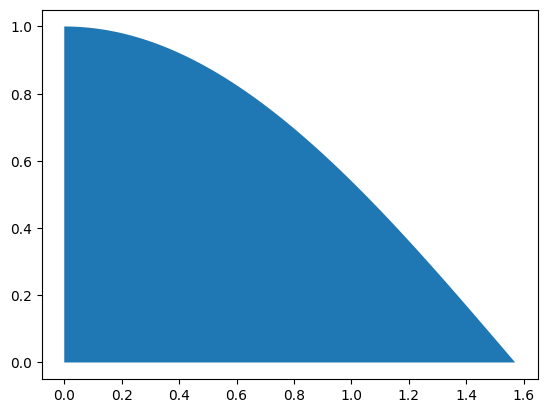

In [ ]:
# Ejemplo

import numpy as np
import matplotlib.pyplot as plt

M =1.0 # mayor que sen(x) en [0,pi/2]
f = lambda x: np.cos(x)
x = np.linspace(0,np.pi/2,1000)
plt.fill_between(x,f(x))

Von_Neumann0(f,M,0,np.pi/2,1000)

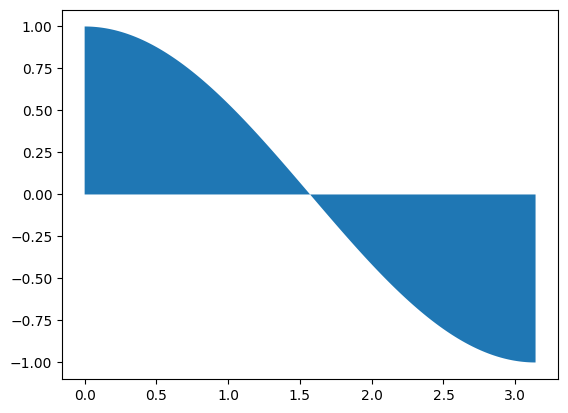

In [ ]:
# Ejemplo3:
W0 =1.0 # mayor que sen(x) en [0,pi/2]
f = lambda x: np.cos(x)
x = np.linspace(0,np.pi,1000)
plt.fill_between(x,f(x))


**Tarea**

https://nm.mathforcollege.com/mws/gen/07int/mws_gen_int_spe_improper.pdf